O conteúdo das seguintes células são baseadas nos conhecimentos adquiridos
durante a aula 1 do curso de PyTorch e Deep Learning do canal Programação Dinâmica e
implementam redes neurais usando regressão linear

https://www.youtube.com/watch?v=cGxv8tOaA7I&t=3800s$0


In [38]:
import torch
import numpy as np
from torch import nn

In [39]:
class LineNetwork(nn.Module):
# Inicializando
  def __init__(self):
    # Construtor da classe de redes neurais
    super().__init__()
    #self.layers = nn.Linear(1,1) # Usamos essa quando vamos usar apenas 1 camada, mas o layers que vamos usar nesse projeto tem várias camadas, por isso método sequential.
    self.layers = nn.Sequential(
        nn.Linear(1,1)
    )

# Como a rede computa
  def forward(self, x):
    return self.layers(x)


In [50]:
class SineNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Criamos uma rede com 2 camadas ocultas e ativações não-lineares
        self.layers = nn.Sequential(
            # 1ª Camada: Recebe 1 entrada (x) e espalha para 32 neurônios ocultos
            nn.Linear(in_features=1, out_features=32),

            # Ativação Não-Linear: Permite que a rede "dobre" o espaço matemático
            nn.Tanh(), # Tanh (Tangente Hiperbólica) é excelente para funções suaves e cíclicas como o Seno!

            # 2ª Camada Oculta: Conecta os 32 neurônios a outros 32 neurônios ocultos
            nn.Linear(in_features=32, out_features=32),
            nn.Tanh(),

            # Camada de Saída: Consolida os 32 neurônios ocultos na nossa única saída final (y)
            nn.Linear(in_features=32, out_features=1)
        )

    def forward(self, x):
        return self.layers(x)

In [40]:
from torch.utils.data import Dataset, DataLoader
import torch.distributions.uniform as urand

In [41]:
# Cria base de dados que vamos usar
class AlgebraicDataset(Dataset): # Nosso dataset deriva do dataset do pytorch ent ajuda no dataloader
  def __init__(self, funcao, intervalo, nsamples):  #esse eh os parametros do meu dataset
    X = urand.Uniform(intervalo[0], intervalo[1]).sample([nsamples]) # gero um x com varios valores aleatorios
    self.data = [(x,funcao(x)) for x in X] # meus dados viram um par ordenado dos valores aleatorios gerados

  def __len__(self):
    return len(self.data)

  def __getitem__(self, index):
    return self.data[index]

In [56]:
line = lambda x: 2*x + 3 # funcao que usamos no dataset algebrico
intervalo = (-10, 10)
train_nsamples = 10000 # quantidade de amostras para usar na previsao

test_nsamples = 2000

In [58]:
# datasets com funcao seno

import numpy as np

# A função geradora agora TEM que ser o seno!
funcao_seno = lambda x: np.sin(x)

# Recrie os datasets e os dataloaders com o seno
train_dataset = AlgebraicDataset(funcao_seno, intervalo, train_nsamples)
test_dataset = AlgebraicDataset(funcao_seno, intervalo, test_nsamples)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True)

/tmp/ipykernel_1446/1354747334.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  funcao_seno = lambda x: np.sin(x)


In [43]:
# Carrega a nossa base de dados

#train_dataset = AlgebraicDataset(line, intervalo, train_nsamples)
#test_dataset = AlgebraicDataset(line, intervalo, test_nsamples)

#train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True) #  batch_size=train_nsamples # Coloquei igual a 32 para gerar pequenas amostrinhas de passagem de dados para ver a previsao melhorar

#batch_size : serve para ler de pouquinho em poquinho principalmente para grandes volumes, mas como o nosso eh pouco, vamos ler tudo de cada vez (=train_nsamples)
#shuffle=True: serve para TRUE embaralhar cada conjuntinho de dados do zero para os minipacotes lidos de acordo com o batch_size, ajuda na variabilidade dos dados

#test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True) # batch_size=test_nsamples



Hiperparâmetros de Otimização

In [44]:
# serve para saber onde ta rodando o código e o pytorch consegue identificar onde
# cuda eh gpu, e gpu é muito melhor e mais rápido que cpu, tipo para imagens
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Rodando na {device}")

Rodando na cpu


In [51]:
# Cria meu modelo passando gpu ou cpu, nesse caso cpu
# model = LineNetwork().to(device) # camada unica

model = SineNetwork().to(device) # testei fazer esse modelo do seno pra testar arquitetura multi camadas

In [52]:
#aqui vamos começar a corrigir o erro
# Função de perda
# Erro Quadrático Médio eh oq usaremos
lossfunc = nn.MSELoss()

# Gradiente Descendente Estocástico
# SGD = Stochastic Gradient Descent
# Método guloso que não percebe se esta no mínimo global ou local
# Calculamos o erro para uma aprte do conjunto de dados, que eh aquele pedaço que passamos no batch_size no DataLoader
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3) # lr= taxa de aprendizado, no caso 0,001

In [53]:
def train(model, dataloader, lossfunc, optimizer):
  model.train()
  cumloss = 0.0
  for X, y in dataloader: # X é o dado e Y é o rótulo/resposta/verdade que quero aprender a pré-dizer
    X = X.unsqueeze(1).float().to(device) # faz o vetor virar tensores de 1 dimensão, com cada valor desse vetor x virando um vetor separado dentro desse vetor principal
    y = y.unsqueeze(1).float().to(device)

    pred = model(X)
    loss = lossfunc(pred, y) # passa o que q eu prediz com o 'pred' e oq que eh o valor real com 'y'

    # zera os gradientes acumulados, mas no geral vc nao quer acumular mesmo
    optimizer.zero_grad()
    # computa os gradientes
    loss.backward() # retroprograpagação com os gradientes de uma camada para a outra, usa regra da cadeia pra ir de trás pra frente
    # anda, de fato, na direcao que reduz o erro local
    optimizer.step()

    cumloss += loss.item() # usa o item pra pegar o float do gradiente pq loss eh um tensor de 1 dimensao

  return cumloss/len(dataloader)

def test(model, dataloader, lossfunc):
  model.eval() # forma de só avaliar o modelo
  cumloss = 0.0
  with torch.no_grad(): # para falar q nao queremos acumular gradientes
    for X, y in dataloader: # X é o dado e Y é o rótulo/resposta/verdade que quero aprender a pré-dizer
      X = X.unsqueeze(1).float().to(device) # faz o vetor virar tensores de 1 dimensão, com cada valor desse vetor x virando um vetor separado dentro desse vetor principal
      y = y.unsqueeze(1).float().to(device)

      pred = model(X)
      loss = lossfunc(pred, y) # passa o que q eu prediz com o 'pred' e oq que eh o valor real com 'y'
      cumloss += loss.item() # usa o item pra pegar o float do gradiente pq loss eh um tensor de 1 dimensao


  return cumloss/len(dataloader)

Treinando a rede

In [60]:
# MATPLOTLIB PARA VISUALIZAÇÃO GRÁFICA DO TREINAMENTO
import matplotlib.pyplot as plt


def plot_comparinson(f, model, interval=(-10, 10), nsamples=150):
  fig, ax = plt.subplots(figsize=(10, 10))

  ax.grid(True, which='both')
  ax.spines['left'].set_position('zero')
  ax.spines['right'].set_color('none')
  ax.spines['bottom'].set_position('zero')
  ax.spines['top'].set_color('none')

  samples = np.linspace(interval[0], interval[1], nsamples)
  model.eval()
  with torch.no_grad():
    pred = model(torch.tensor(samples).unsqueeze(1).float().to(device))

  ax.plot(samples, list(map(f, samples)), "o", label="ground truth")
  ax.plot(samples, pred.cpu(), label="model")
  plt.legend()
  plt.show()

Epoch: 0; Train Loss: 1.063621461581879


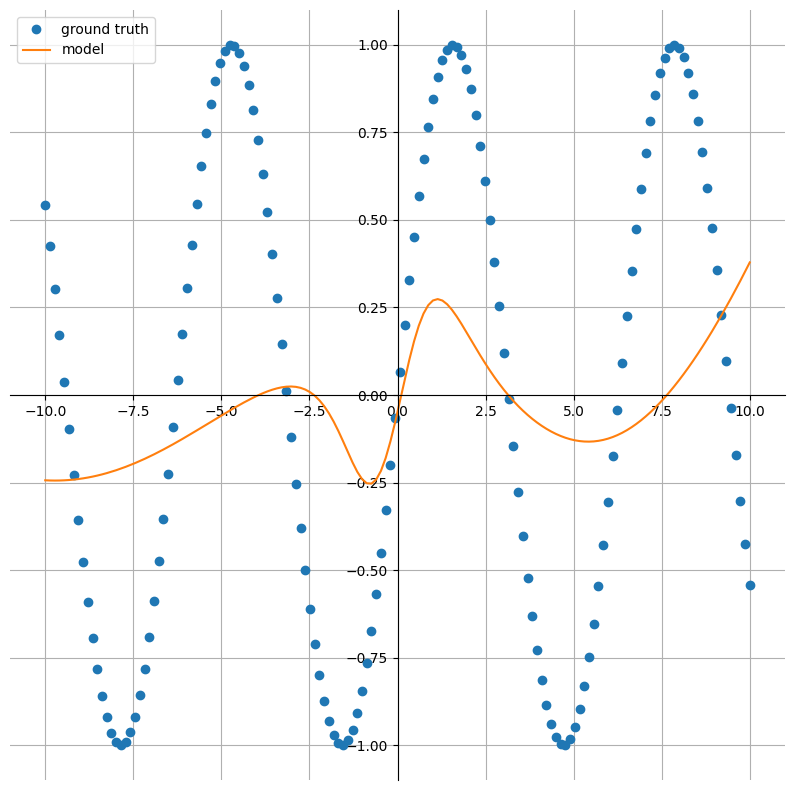

Epoch: 10; Train Loss: 0.24304558374820806


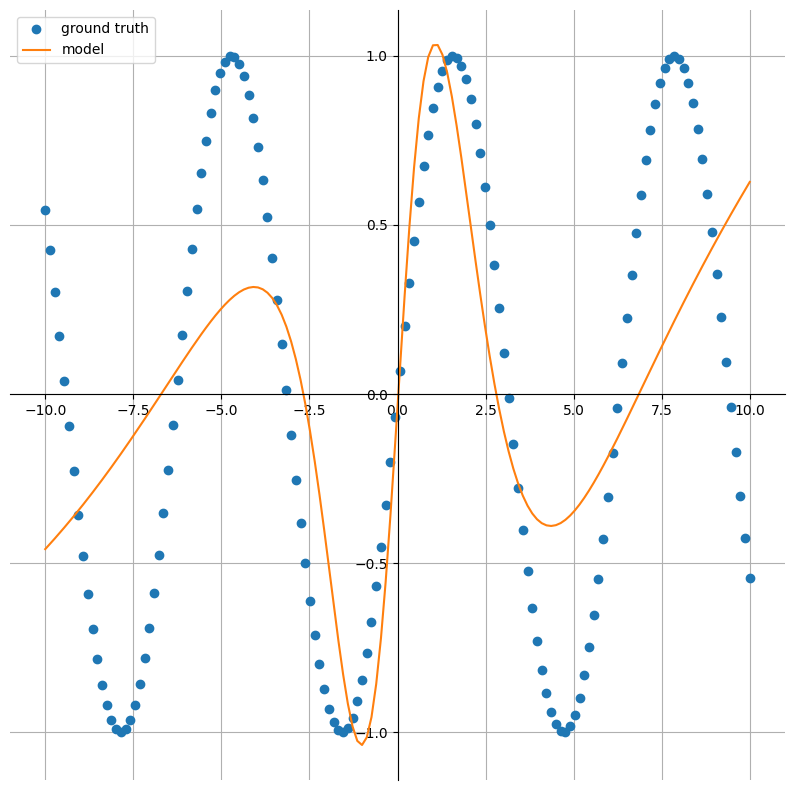

Epoch: 20; Train Loss: 0.21413063331724355


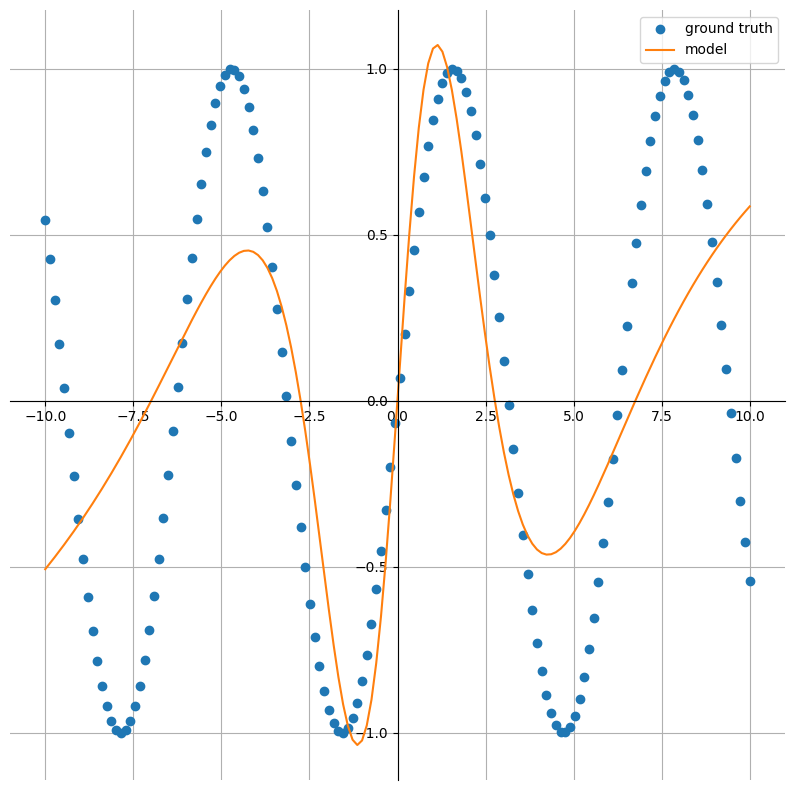

Epoch: 30; Train Loss: 0.19092713786771123


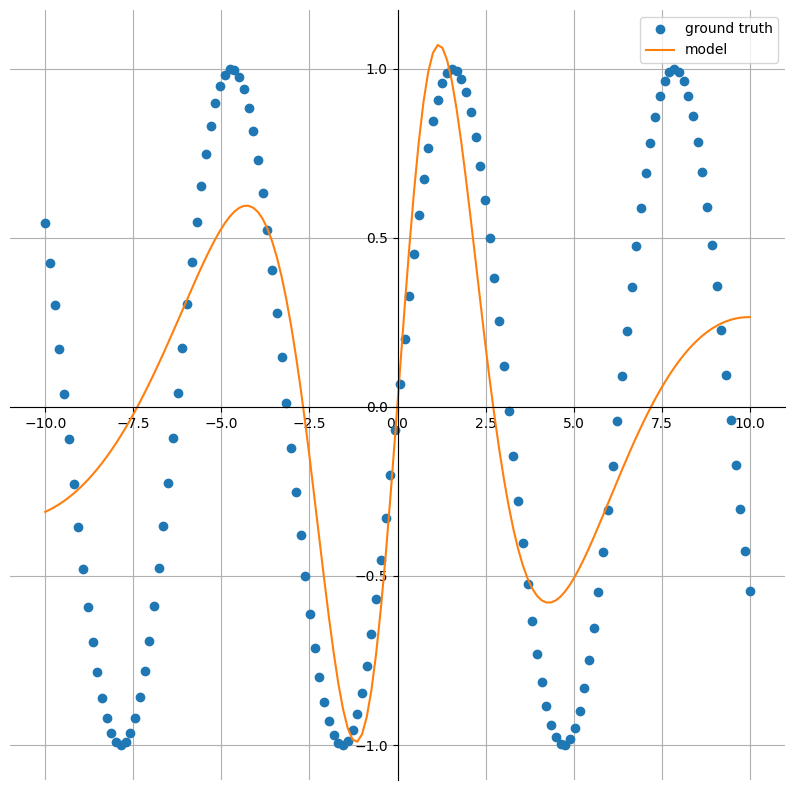

Epoch: 40; Train Loss: 0.16209172190854343


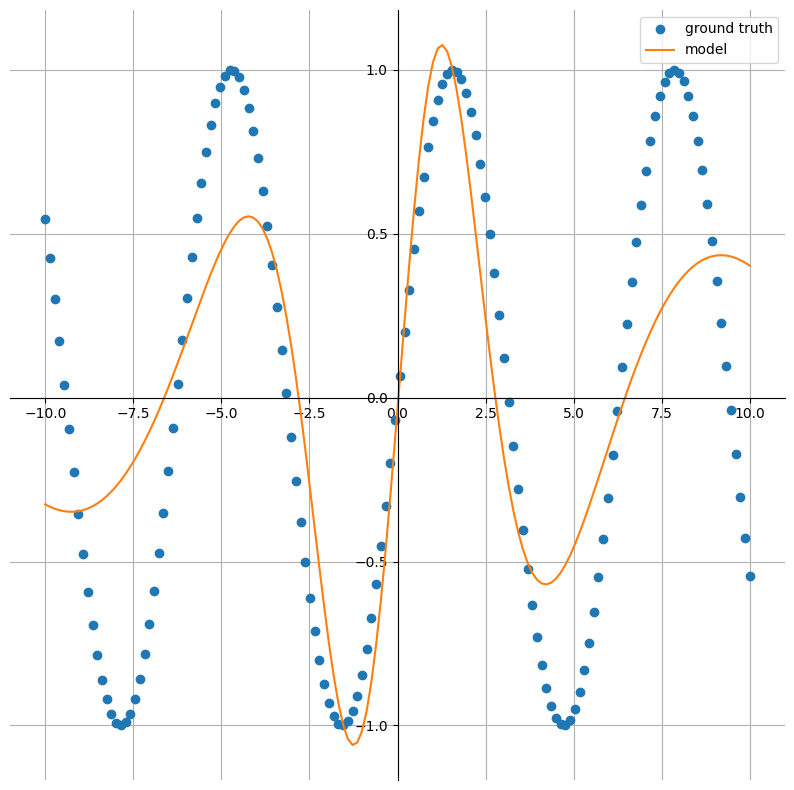

Epoch: 50; Train Loss: 0.14204233991928375


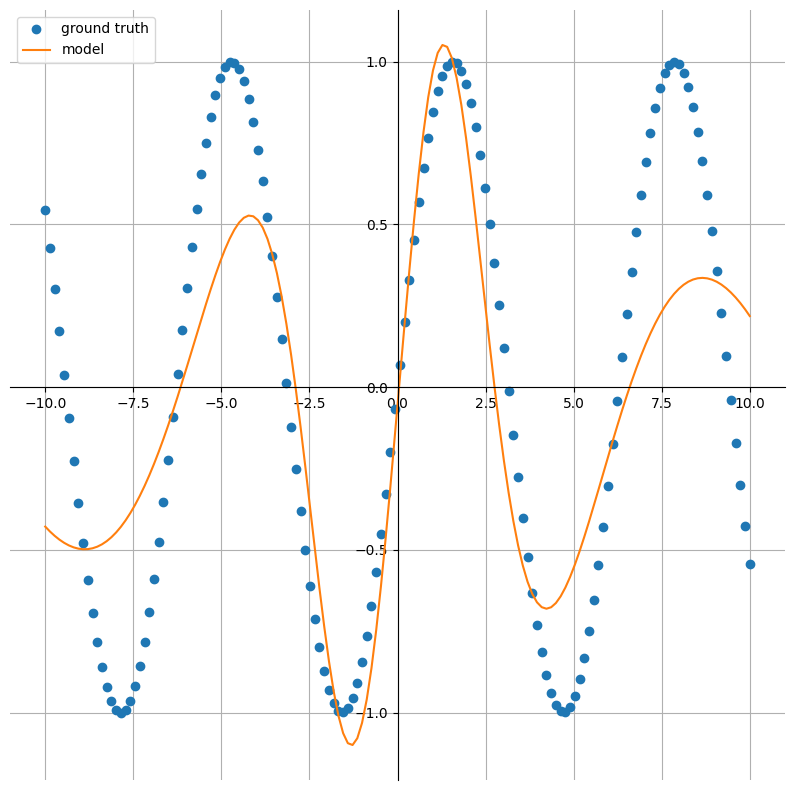

Epoch: 60; Train Loss: 0.11982204916235357


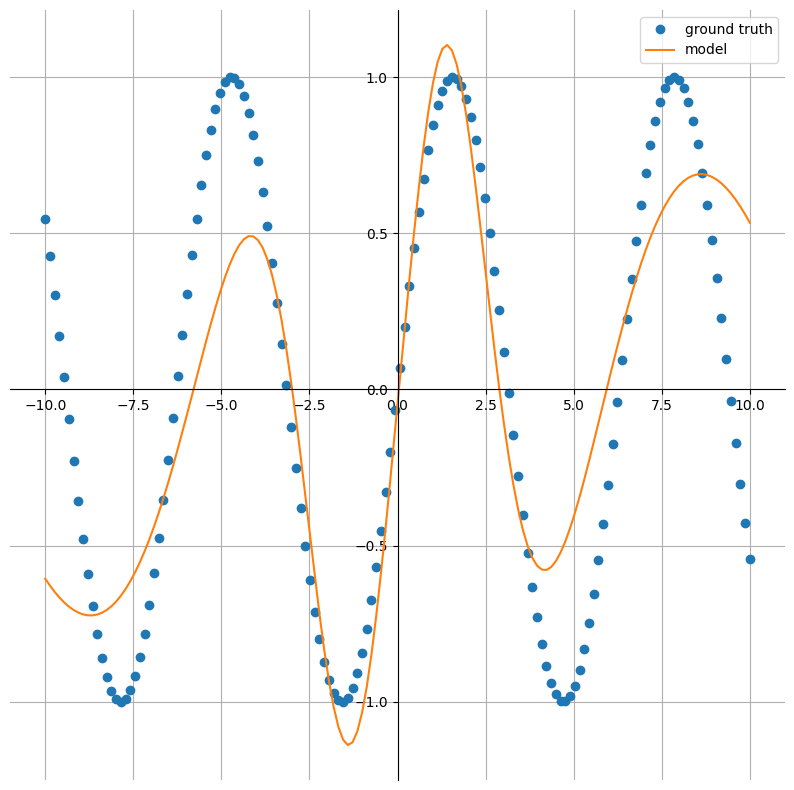

Epoch: 70; Train Loss: 0.10190252019479253


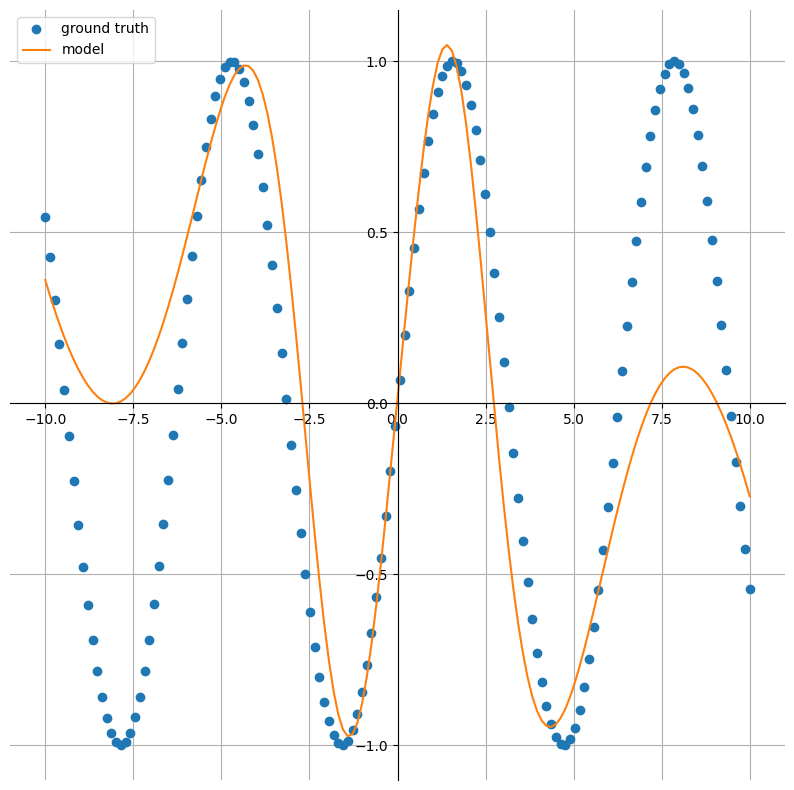

Epoch: 80; Train Loss: 0.08293519289301227


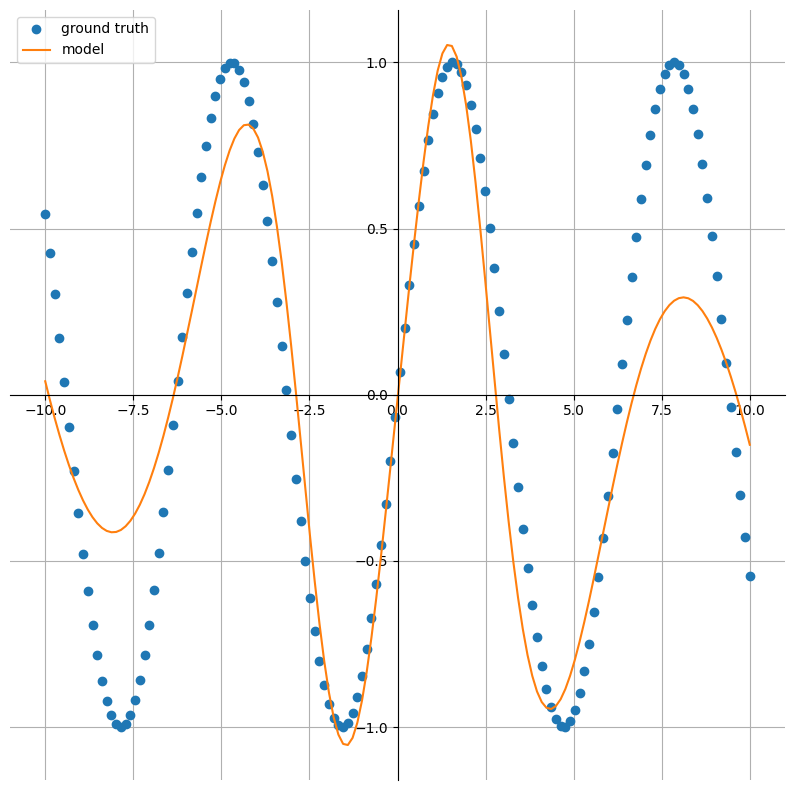

Epoch: 90; Train Loss: 0.06831570043445775


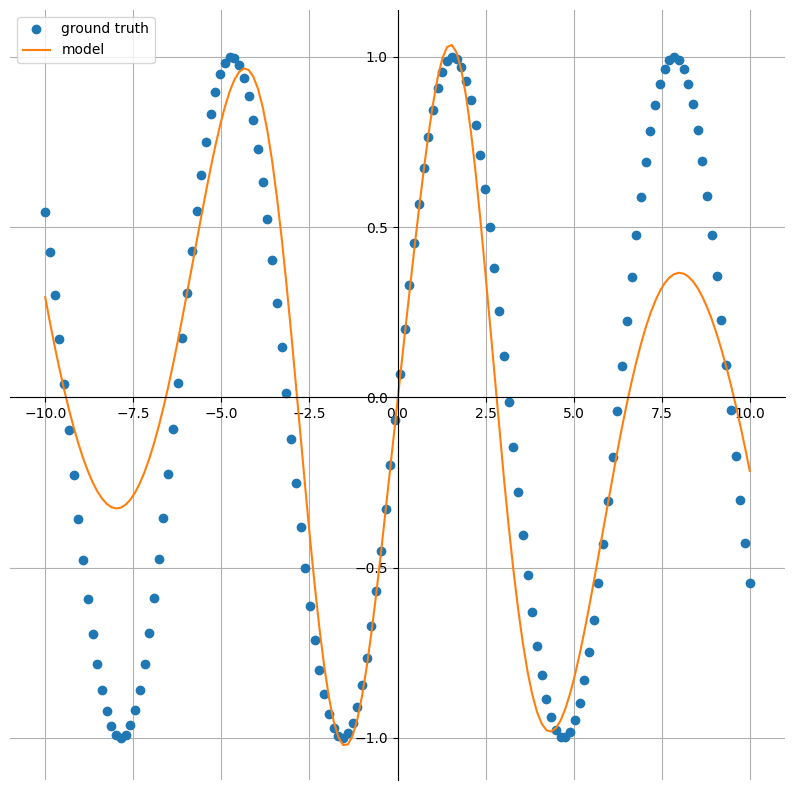

Epoch: 100; Train Loss: 0.05707613721537514


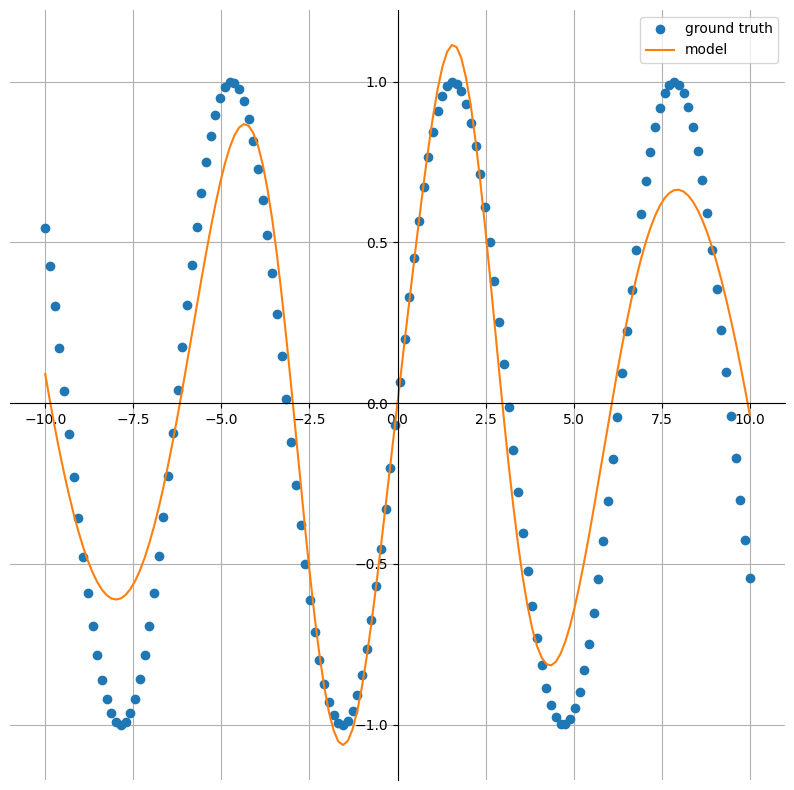

Test Loss: 0.04274206372007491


In [61]:
epochs = 101 # quantidade de vezes que vamos treinar a rede
for t in range(epochs):
  train_loss = train(model, train_dataloader, lossfunc, optimizer) #erro de treinamento
  if t % 10 == 0:
    print(f"Epoch: {t}; Train Loss: {train_loss}")
    plot_comparinson(np.sin, model)

test_loss = test(model, test_dataloader, lossfunc)
print(f"Test Loss: {test_loss}")